In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split 
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom

In [2]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [3]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [4]:
protons = protons[(protons['height'] < 100) & (protons['width'] < 400)]
deuterons = deuterons[(deuterons['height'] < 100) & (deuterons['width'] < 400)]

In [5]:
protons.shape, deuterons.shape

((6291, 37), (5115, 37))

In [6]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(399, 99, 399, 99)

In [7]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

<Axes: >

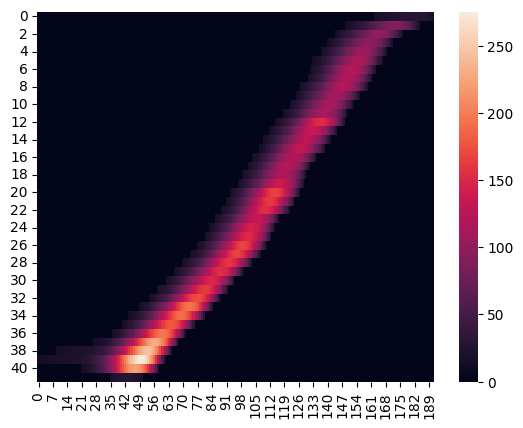

In [8]:
i = 14
sns.heatmap(protons['image_intensity'].iloc[i])

In [9]:
int(np.argmax(protons['image_intensity'].iloc[i][0]))

180

In [10]:
pv = []                                                 # vertex
pe = []                                                 # end   
for idx, row in protons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    pv.append(vertex)
    pe.append(end)

pv = np.array(pv)
pe = np.array(pe)

dv = []                                                 # vertex
de = []                                                 # end   
for idx, row in deuterons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    dv.append(vertex)
    de.append(end)

np.int64(-348)

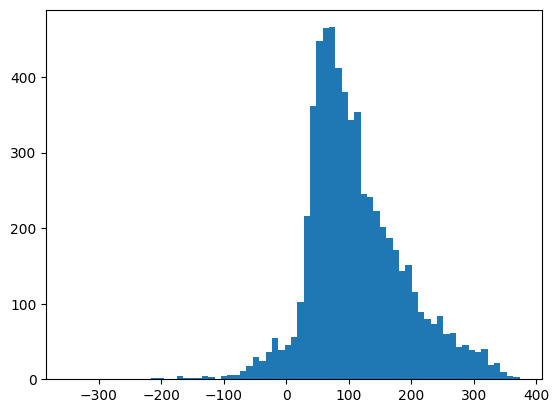

In [11]:
plt.hist(pv - pe, bins='auto')
min(pv-pe)

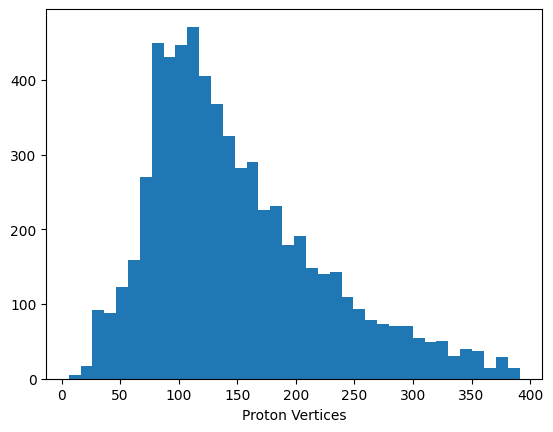

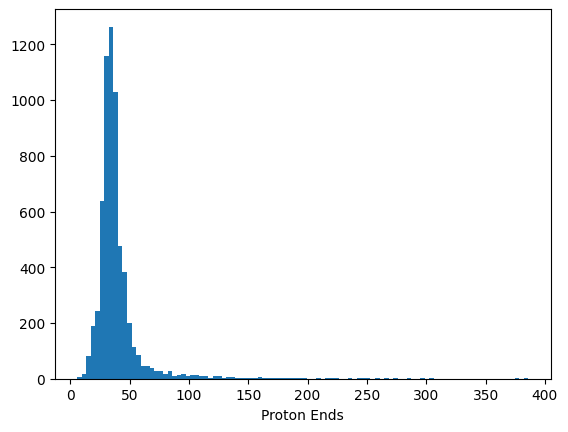

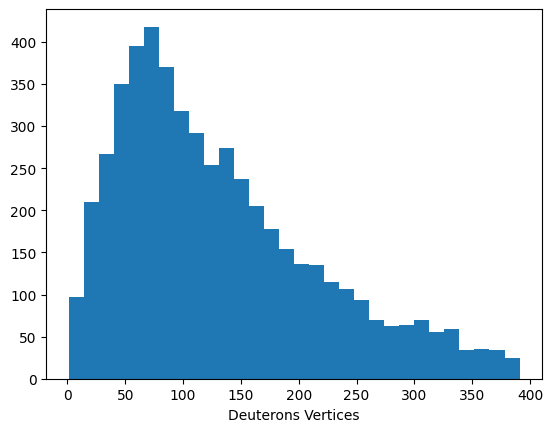

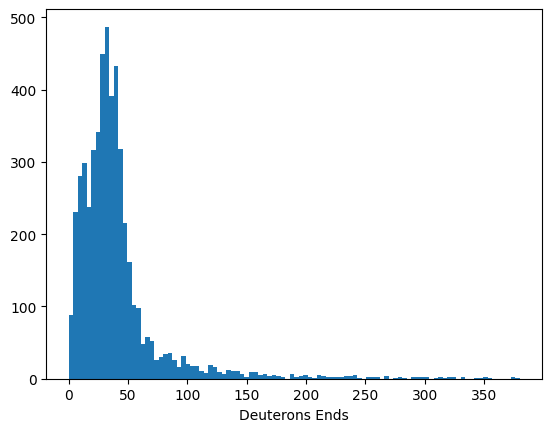

In [12]:
plt.hist(pv, bins='auto'); plt.xlabel('Proton Vertices'); plt.show()
plt.hist(pe, bins=100); plt.xlabel('Proton Ends'); plt.show()
plt.hist(dv, bins='auto'); plt.xlabel('Deuterons Vertices'); plt.show()
plt.hist(de, bins=100); plt.xlabel('Deuterons Ends'); plt.show()

<Axes: >

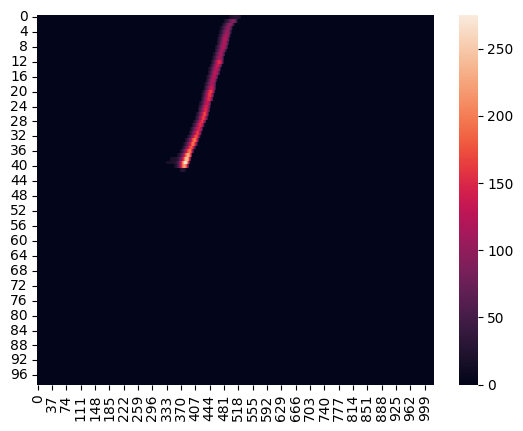

In [13]:
pad = pad_image(protons['image_intensity'].iloc[i])
sns.heatmap(pad)

In [14]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [15]:
p = [] 
d = []

for idx, row in protons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    p.append(padded)

for idx, row in deuterons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    d.append(padded)

p = np.array(p)
d = np.array(d)

p_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p])
d_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d])

In [16]:
imgpv = []                                                 # vertex
imgpe = []                                                 # end   
for img in p_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgpv.append(vertex)
    imgpe.append(end)

imgdv = []                                                 # vertex
imgde = []                                                 # end   
for img in d_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgdv.append(vertex)
    imgde.append(end)

0


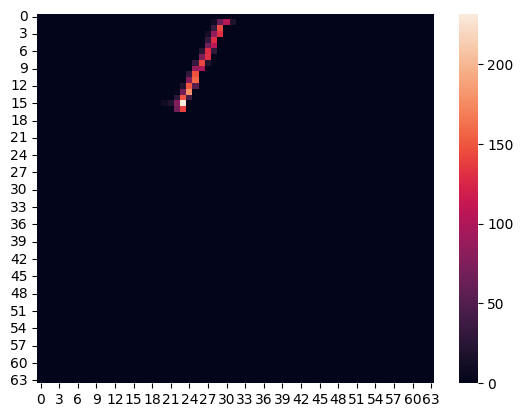

In [17]:
i = 2
sns.heatmap(p_d[i]); print(np.argmax(p_d[i][0]))

<Axes: >

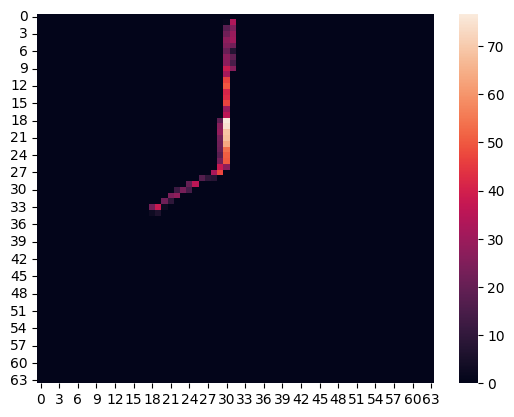

In [18]:
sns.heatmap(d_d[3])

In [19]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [27]:
class Discriminator(nn.Module):
    def __init__(self, input_hw=(64, 64)):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=2, padding=1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),  
            nn.Conv2d(512, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1) if x.ndim == 3 else x
        return self.model(x).view(-1)

In [28]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss()

In [29]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

G = CAE(input_hw=(64, 64), latent=16).to(device)
D = Discriminator(input_hw=(64, 64)).to(device)

optim_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [30]:
X = torch.tensor(p_d, dtype=torch.float32).to(device)  # shape (N, H, W)

train_size = int(0.8 * len(X))
val_size = len(X) - train_size

train, val = random_split(X, [train_size, val_size])

train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader = DataLoader(val, batch_size=32, shuffle=False)

In [59]:
epochs = 100

lambda_mse = 30.0

In [32]:
train_losses = []
val_losses = []

In [ ]:
# checkpoint = {
#     'epoch': epoch,
#     'generator_state_dict': G.state_dict(),
#     'discriminator_state_dict': D.state_dict(),
#     'optim_G_state_dict': optim_G.state_dict(),
#     'optim_D_state_dict': optim_D.state_dict(),
#     'train_losses': train_losses,
#     'val_losses': val_losses
# }

# torch.save(checkpoint, "/Users/user/data/research/proton-deuteron/models/checkpoint_epoch_%03d.pth" % epoch)

In [ ]:
# checkpoint = torch.load("checkpoint_epoch_080.pth", map_location=device)

# G.load_state_dict(checkpoint['generator_state_dict'])
# D.load_state_dict(checkpoint['discriminator_state_dict'])
# optim_G.load_state_dict(checkpoint['optim_G_state_dict'])
# optim_D.load_state_dict(checkpoint['optim_D_state_dict'])

# start_epoch = checkpoint['epoch'] + 1
# train_losses = checkpoint['train_losses']
# val_losses = checkpoint['val_losses']

# G.to(device)
# D.to(device)

Epoch [1/100]  G_Loss: 50.0439  D_Loss: 0.1882
Epoch 1/100: Train Loss = 50.0439, Val Loss = 6.8108
Epoch [2/100]  G_Loss: 45.9119  D_Loss: 0.2342
Epoch 2/100: Train Loss = 45.9119, Val Loss = 6.8014
Epoch [3/100]  G_Loss: 45.7003  D_Loss: 0.2098
Epoch 3/100: Train Loss = 45.7003, Val Loss = 7.4057
Epoch [4/100]  G_Loss: 46.8396  D_Loss: 0.2203
Epoch 4/100: Train Loss = 46.8396, Val Loss = 7.3397
Epoch [5/100]  G_Loss: 46.7595  D_Loss: 0.2064
Epoch 5/100: Train Loss = 46.7595, Val Loss = 7.0290
Epoch [6/100]  G_Loss: 46.8940  D_Loss: 0.1902
Epoch 6/100: Train Loss = 46.8940, Val Loss = 7.4651
Epoch [7/100]  G_Loss: 48.9441  D_Loss: 0.2108
Epoch 7/100: Train Loss = 48.9441, Val Loss = 6.9764
Epoch [8/100]  G_Loss: 49.9051  D_Loss: 0.1899
Epoch 8/100: Train Loss = 49.9051, Val Loss = 7.3511
Epoch [9/100]  G_Loss: 52.9577  D_Loss: 0.1793
Epoch 9/100: Train Loss = 52.9577, Val Loss = 7.3881
Epoch [10/100]  G_Loss: 55.2757  D_Loss: 0.1865
Epoch 10/100: Train Loss = 55.2757, Val Loss = 7.335

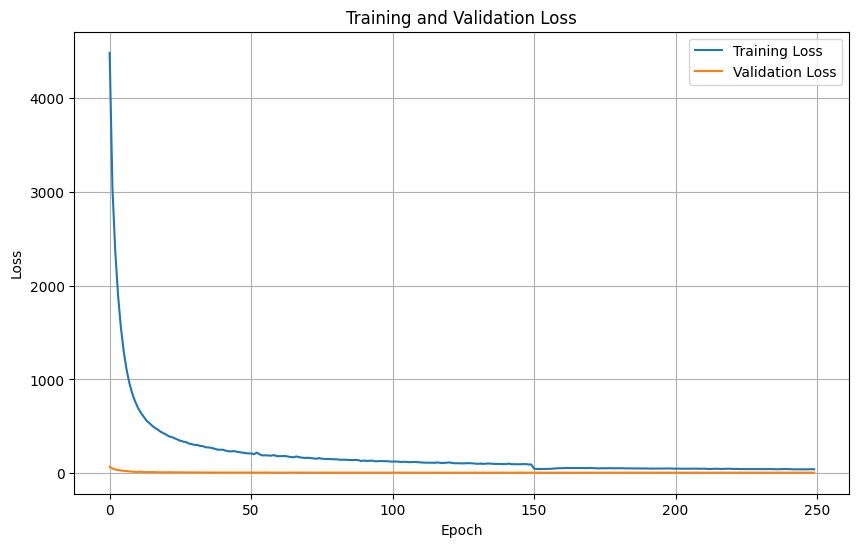

In [60]:
for epoch in range(epochs):
    # Training phase
    G.train()
    D.train()

    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    train_loss = 0.0
    train_batches = 0
    
    for xb in train_loader:

        xb = xb.to(device)

        optim_D.zero_grad()

        real_labels = torch.ones(xb.size(0), device=device)
        fake_labels = torch.zeros(xb.size(0), device=device)

        real_preds = D(xb)
        d_loss_real = bce_loss(real_preds, real_labels)

        with torch.no_grad():
            fake_imgs = G(xb)
        fake_preds = D(fake_imgs)
        d_loss_fake = bce_loss(fake_preds, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optim_D.step()

        optim_G.zero_grad()

        recon = G(xb)
        preds_fake = D(recon)

        gan_loss = bce_loss(preds_fake, real_labels)

        recon_loss = mse_loss(recon, xb)

        g_loss = gan_loss + lambda_mse * recon_loss
        g_loss.backward()
        optim_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

        avg_train_loss = g_loss_epoch / len(train_loader)
        avg_d_loss = d_loss_epoch / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}]  G_Loss: {g_loss_epoch/len(train_loader):.4f}  D_Loss: {d_loss_epoch/len(train_loader):.4f}")
    
    # Validation phase
    G.eval()
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for xb in val_loader:
            xb = xb.to(device)
            preds = G(xb)
            loss = mse_loss(preds, xb)   # reconstruction quality only
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
G.eval()
test_mse, test_psnr, test_ssim = 0.0, 0.0, 0.0
num_batches = 0

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

with torch.no_grad():
    for xb in val_loader:
        xb = xb.to(device)
        preds = G(xb)

        # Reconstruction loss
        mse_val = mse_loss(preds, xb).item()
        test_mse += mse_val

        # Convert to numpy for PSNR/SSIM
        preds_np = preds.squeeze().cpu().numpy()
        xb_np    = xb.squeeze().cpu().numpy()
        for i in range(len(xb_np)):
            test_psnr += psnr(xb_np[i], preds_np[i], data_range=1236.0)
            test_ssim += ssim(xb_np[i], preds_np[i], data_range=1236.0)

        num_batches += 1

avg_mse  = test_mse / num_batches
avg_psnr = test_psnr / (num_batches * len(xb_np))
avg_ssim = test_ssim / (num_batches * len(xb_np))

print(f"Test MSE:  {avg_mse:.4f}")
print(f"Test PSNR: {avg_psnr:.2f} dB")
print(f"Test SSIM: {avg_ssim:.3f}")

Test MSE:  7.5669
Test PSNR: 160.43 dB
Test SSIM: 2.854


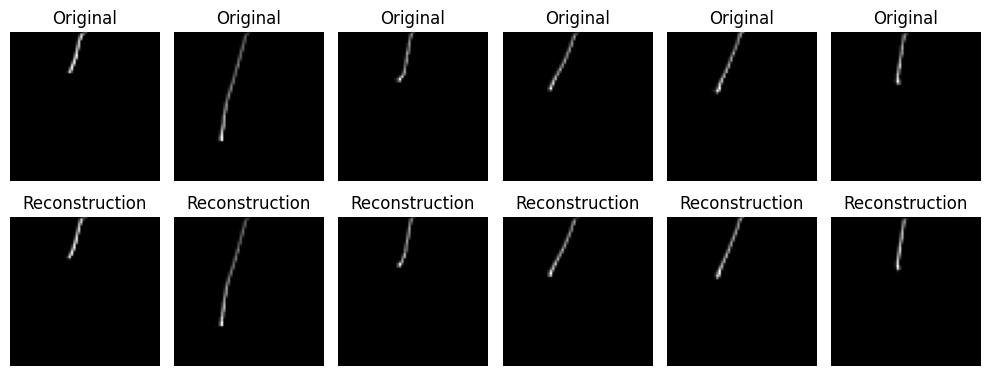

In [62]:
import matplotlib.pyplot as plt

G.eval()
with torch.no_grad():
    xb = next(iter(val_loader))
    xb = xb.to(device)
    preds = G(xb)

n = 6  # number of samples to display
plt.figure(figsize=(10, 4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(xb[i].cpu().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, n, n+i+1)
    plt.imshow(preds[i].cpu().squeeze(), cmap='gray')
    plt.title("Reconstruction")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [63]:
D.eval()
with torch.no_grad():
    realism_score = D(preds).mean().item()
print(f"Average realism score: {realism_score:.3f} (≈0.5 = indistinguishable)")

Average realism score: 0.521 (≈0.5 = indistinguishable)


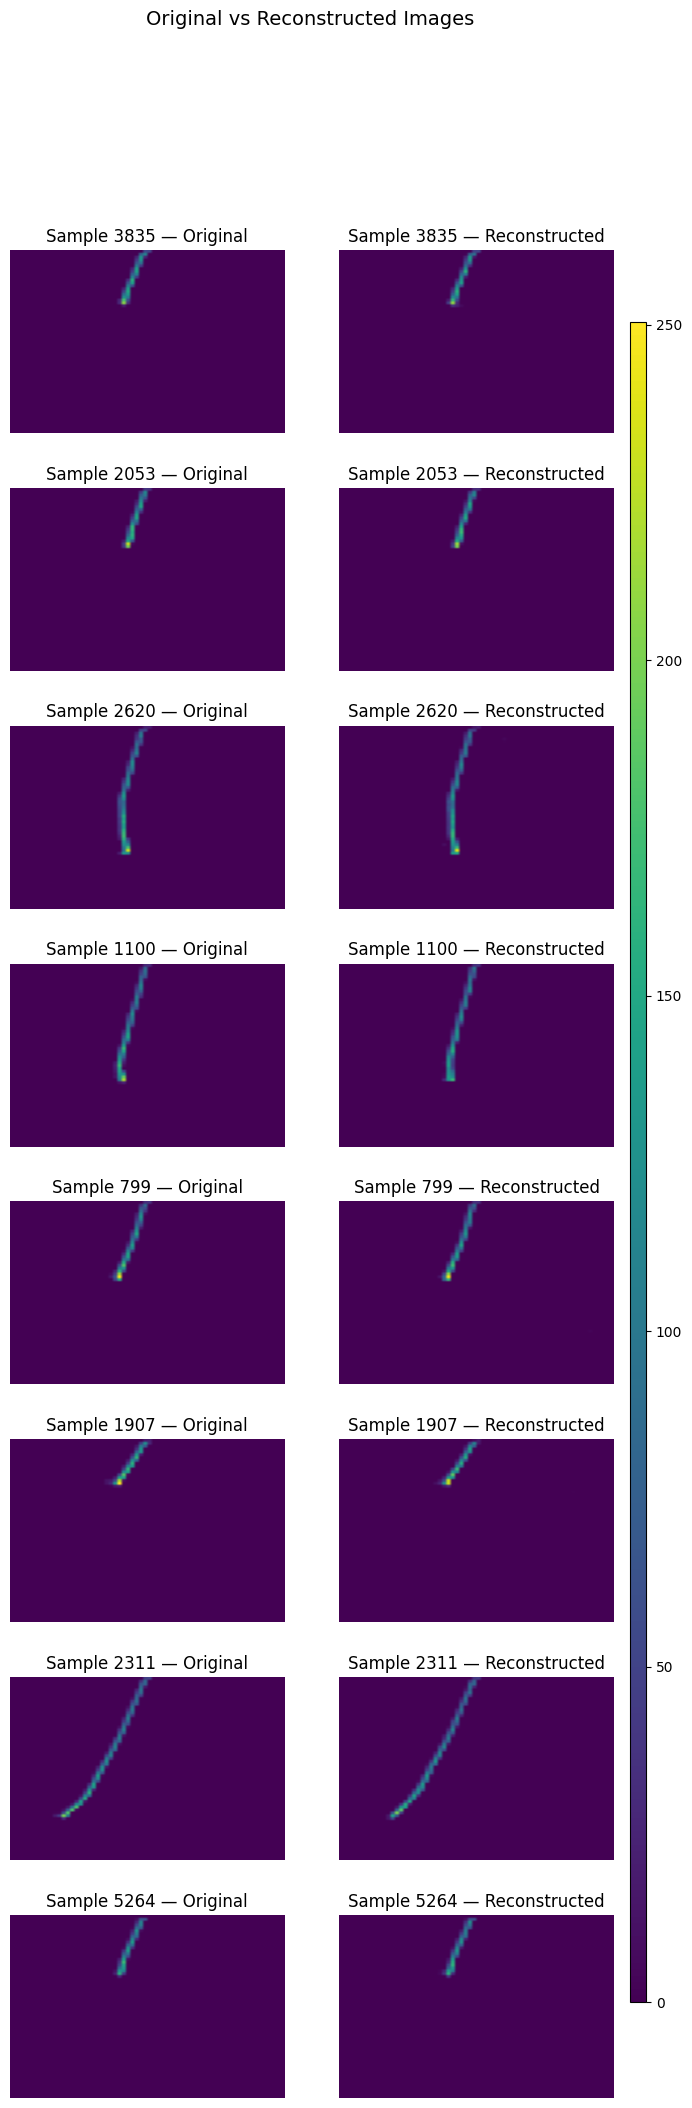

In [66]:
G.eval()

N = 8
X_cpu = X.detach().cpu().numpy()             # full dataset, shape (N_total, H, W)
sample_idx = np.random.choice(len(X_cpu), N, replace=False)
X_sample = X[sample_idx].to(device)          # tensor shape (N, H, W)

# Run through model
with torch.no_grad():
    recons = G(X_sample).cpu().numpy()   # (N, H, W)

# Original images
X_orig = X_sample.cpu().numpy()             # (N, H, W)

# common vmin/vmax for fair comparison
vmin = min(X_orig.min(), recons.min())
vmax = max(X_orig.max(), recons.max())

# Plot side-by-side original / reconstructed for each sample
fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
if N == 1:
    axes = np.expand_dims(axes, 0)

for i in range(N):
    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    im1 = ax1.imshow(X_orig[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax1.set_title(f"Sample {sample_idx[i]} — Original")
    ax1.axis('off')

    im2 = ax2.imshow(recons[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax2.set_title(f"Sample {sample_idx[i]} — Reconstructed")
    ax2.axis('off')

# add single colorbar on the right
fig.subplots_adjust(right=0.88, hspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax)
plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.show()

Inference device: mps
recon_all.shape: (5032, 64, 64)
latent_vectors.shape: (5032, 16)
RE_per_sample.shape: (5032,)


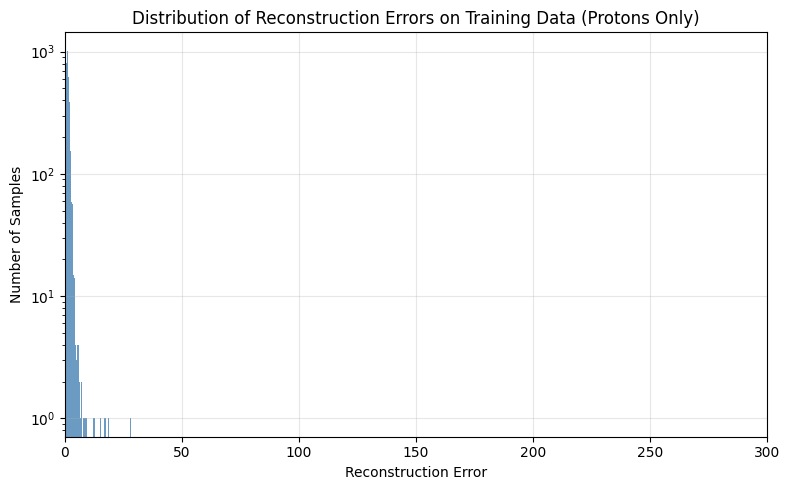

In [67]:
G.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

G.to(device_inf)

X_np = torch.stack([train[i] for i in range(len(train))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = G.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = G(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = G.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = G.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Training Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (1259, 64, 64)
latent_vectors.shape: (1259, 16)
RE_per_sample.shape: (1259,)


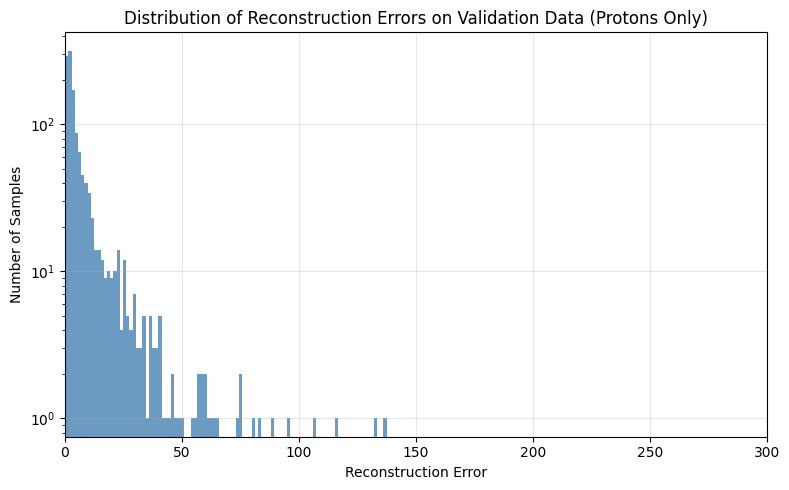

In [68]:
G.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

G.to(device_inf)

X_np = torch.stack([val[i] for i in range(len(val))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = G.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = G(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = G.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = G.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all.shape: (5115, 64, 64)
latent_vectors.shape: (5115, 16)
RE_per_sample_d.shape: (5115,)


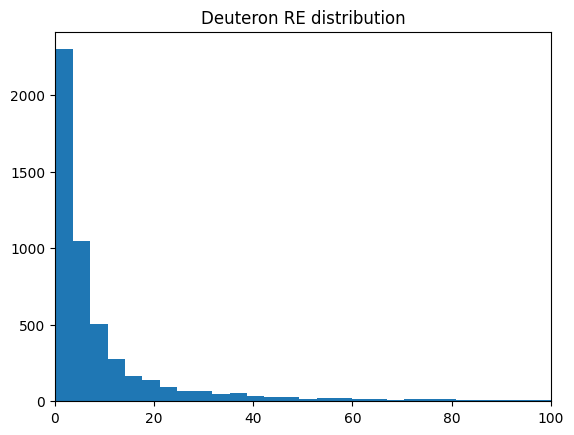

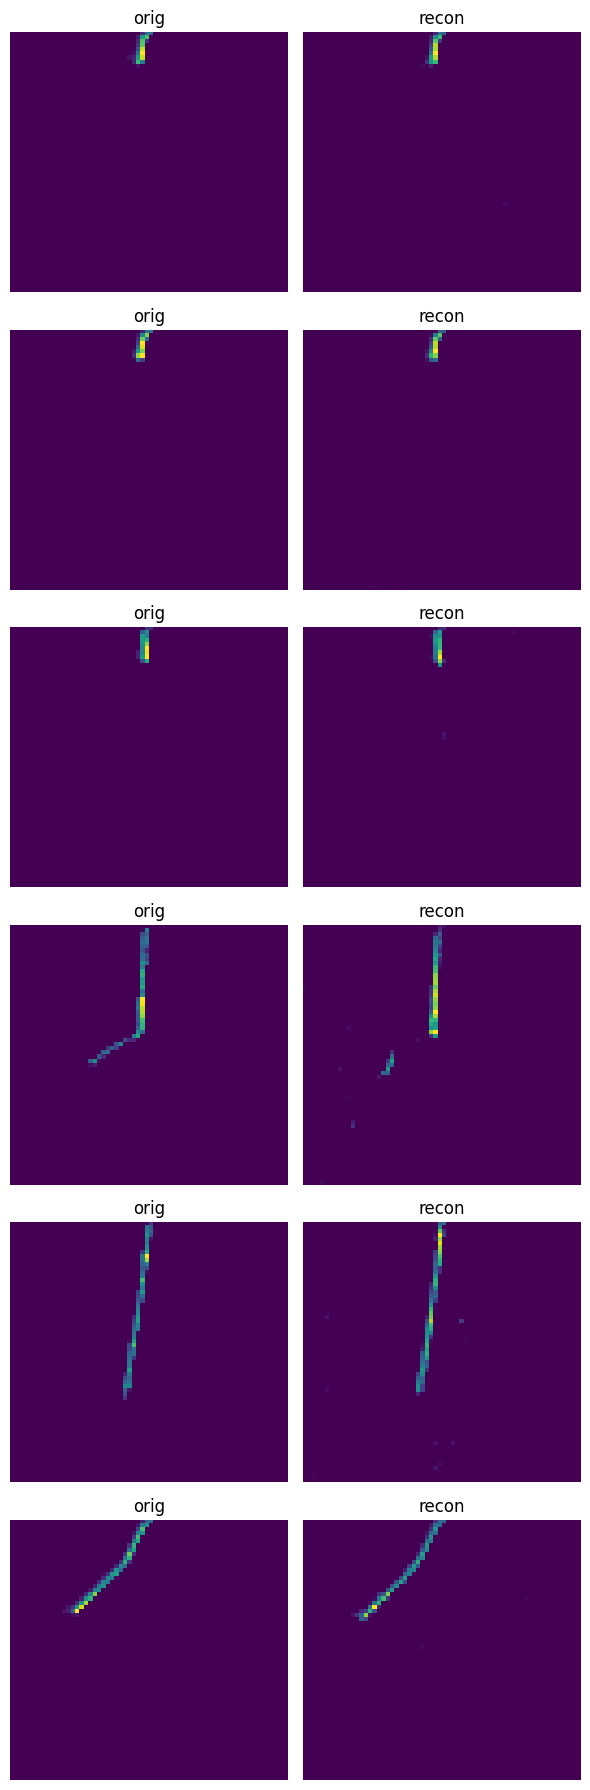

In [69]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
G.eval()
G.to(device_inf)

Xd_np = d_d.astype(np.float32)          # (N, H, W)
N, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all = np.empty((N, H, W), dtype=np.float32)
latent_dim = G.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = G(xb)                         # (b,H,W)
        recon_all[i:j] = out.cpu().numpy()

        enc = G.encoder(xb.unsqueeze(1))    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = G.fc_enc(z_flat)                # (b,latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all - Xd_np) ** 2).mean(axis=(1, 2))

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

plt.figure()
plt.hist(RE_per_sample_d, bins=100)
plt.xlim(0, 100)
plt.title("Deuteron RE distribution")
plt.show()

k = min(6, N)
fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
for ii in range(k):
    axs[ii,0].imshow(Xd_np[ii], cmap='viridis', aspect='auto'); axs[ii,0].set_title("orig"); axs[ii,0].axis('off')
    axs[ii,1].imshow(recon_all[ii], cmap='viridis', aspect='auto'); axs[ii,1].set_title("recon"); axs[ii,1].axis('off')
plt.tight_layout()
plt.show()

In [70]:
d_d.shape, RE_per_sample_d.shape

((5115, 64, 64), (5115,))

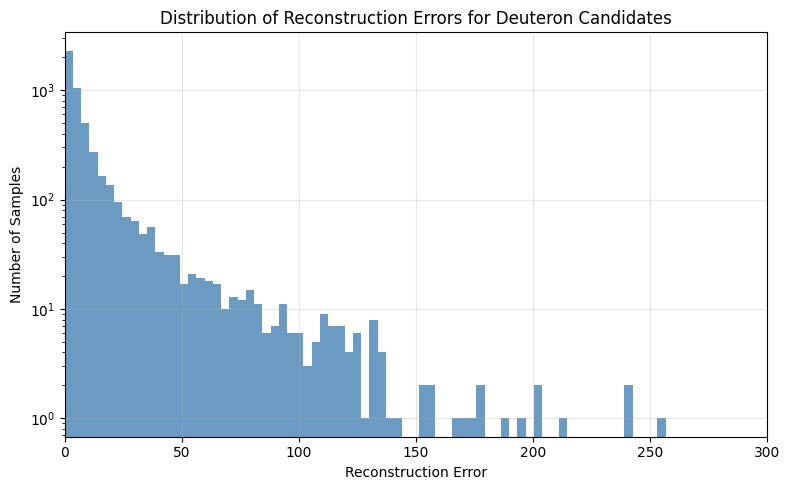

In [71]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_d, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors for Deuteron Candidates")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

(array([2.298e+03, 1.047e+03, 5.060e+02, 2.730e+02, 1.640e+02, 1.360e+02,
        9.500e+01, 7.000e+01, 6.400e+01, 4.800e+01, 5.600e+01, 3.300e+01,
        3.100e+01, 3.100e+01, 1.700e+01, 2.100e+01, 1.900e+01, 1.800e+01,
        1.700e+01, 1.000e+01, 1.300e+01, 1.200e+01, 1.500e+01, 1.100e+01,
        6.000e+00, 7.000e+00, 1.100e+01, 6.000e+00, 6.000e+00, 3.000e+00,
        5.000e+00, 9.000e+00, 7.000e+00, 7.000e+00, 4.000e+00, 6.000e+00,
        1.000e+00, 8.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

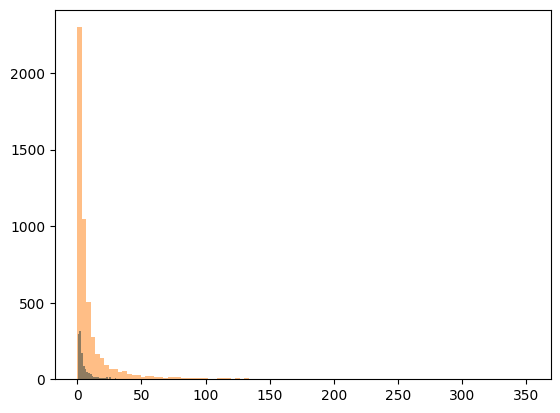

In [72]:
plt.hist(RE_per_sample, bins=100)
plt.hist(RE_per_sample_d, bins=100, alpha=0.5)

In [73]:
a = (np.where(RE_per_sample_d > 50))[0]
a.shape

(259,)

In [74]:
a = np.where(RE_per_sample_d > 25)[0]
n_show = min(len(a), 285)

if n_show == 0:
    print("No samples with RE > 50")
else:
    fig, axs = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))
    if n_show == 1:
        axs = np.expand_dims(axs, 0)

    for i, idx in enumerate(a[:n_show]):
        # independent color scale for original
        vmin_o, vmax_o = Xd_np[idx].min(), Xd_np[idx].max()
        axs[i, 0].imshow(Xd_np[idx], cmap='viridis', vmin=vmin_o, vmax=vmax_o, aspect='auto')
        axs[i, 0].set_title(f"orig [{idx}]")
        axs[i, 0].axis('off')

        # independent color scale for reconstruction
        vmin_r, vmax_r = recon_all[idx].min(), recon_all[idx].max()
        axs[i, 1].imshow(recon_all[idx], cmap='viridis', vmin=vmin_r, vmax=vmax_r, aspect='auto')
        axs[i, 1].set_title(f"recon [{idx}]")
        axs[i, 1].axis('off') 

    plt.tight_layout()
    plt.show()

234

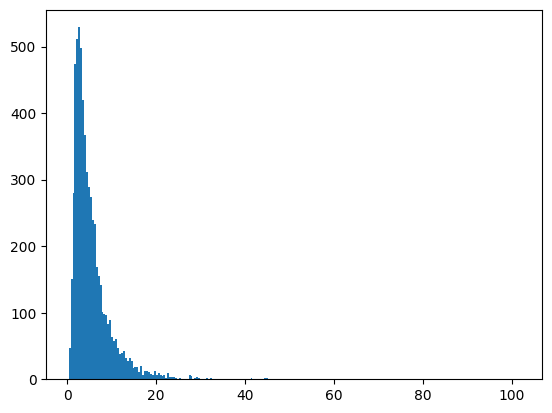

In [518]:

len(plt.hist(RE_per_sample, bins='auto')[1])


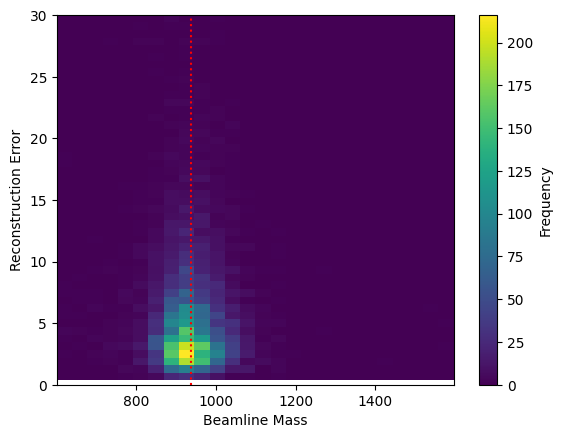

In [519]:
plt.hist2d(protons['beamline_mass'], RE_per_sample, bins=[26, 164]); plt.ylim(0, 30)
plt.colorbar(label='Frequency')
plt.axvline(938.27, linestyle=':', color='r', label=('Proton Mass'))
plt.xlabel('Beamline Mass')
plt.ylabel('Reconstruction Error')
plt.show()

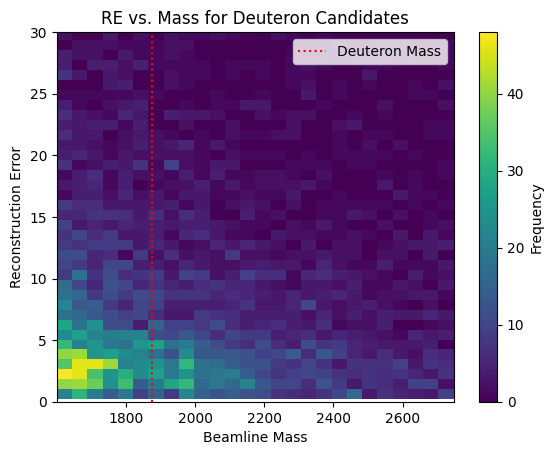

In [520]:
plt.hist2d(deuterons['beamline_mass'], RE_per_sample_d, bins=[26, 410]); plt.ylim(0, 30)
plt.colorbar(label='Frequency')
plt.axvline(1875.6, linestyle=':', color='r', label=('Deuteron Mass'))
plt.xlabel('Beamline Mass')
plt.ylabel('Reconstruction Error')
plt.title('RE vs. Mass for Deuteron Candidates')
plt.legend()
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler, normalize

Zs = StandardScaler().fit_transform(latent_vectors)              # Euclidean-friendly
Zc = normalize(latent_vectors, norm='l2')

In [55]:
from sklearn.mixture import GaussianMixture

lowest_bic, best = np.inf, None
for k in range(2, 4):
    for cov in ['full','tied','diag','spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=0)
        gmm.fit(Zs)
        if gmm.bic(Zs) < lowest_bic:
            lowest_bic, best = gmm.bic(Zs), gmm
labels_gmm = best.predict(Zs)
soft = best.predict_proba(Zs)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

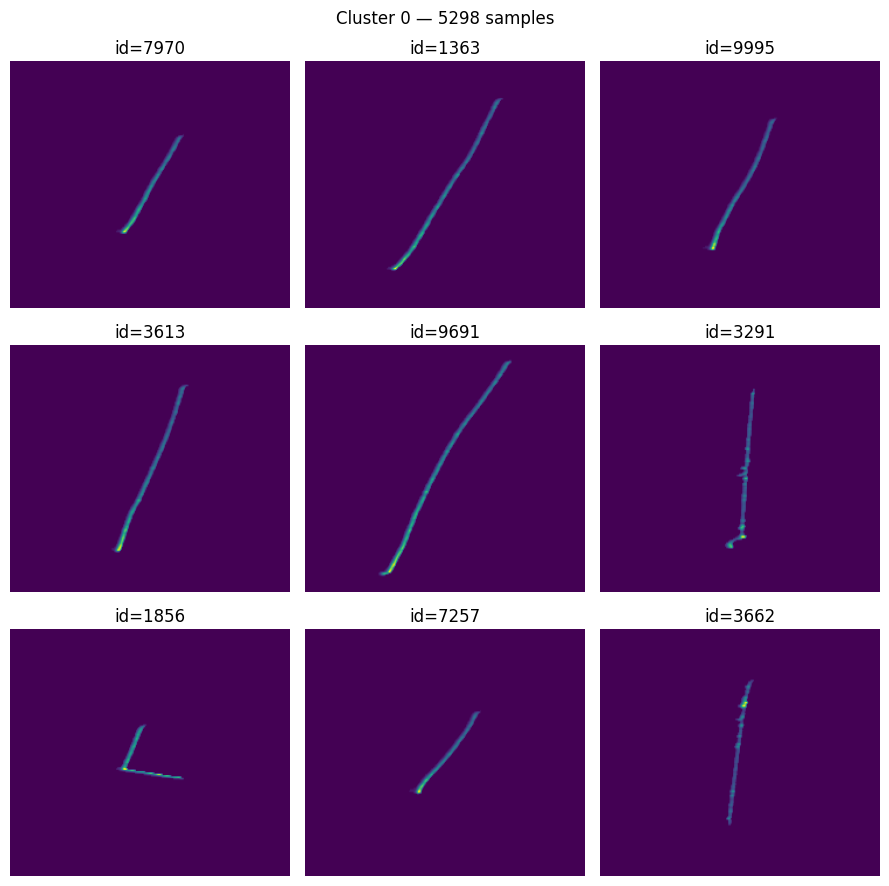

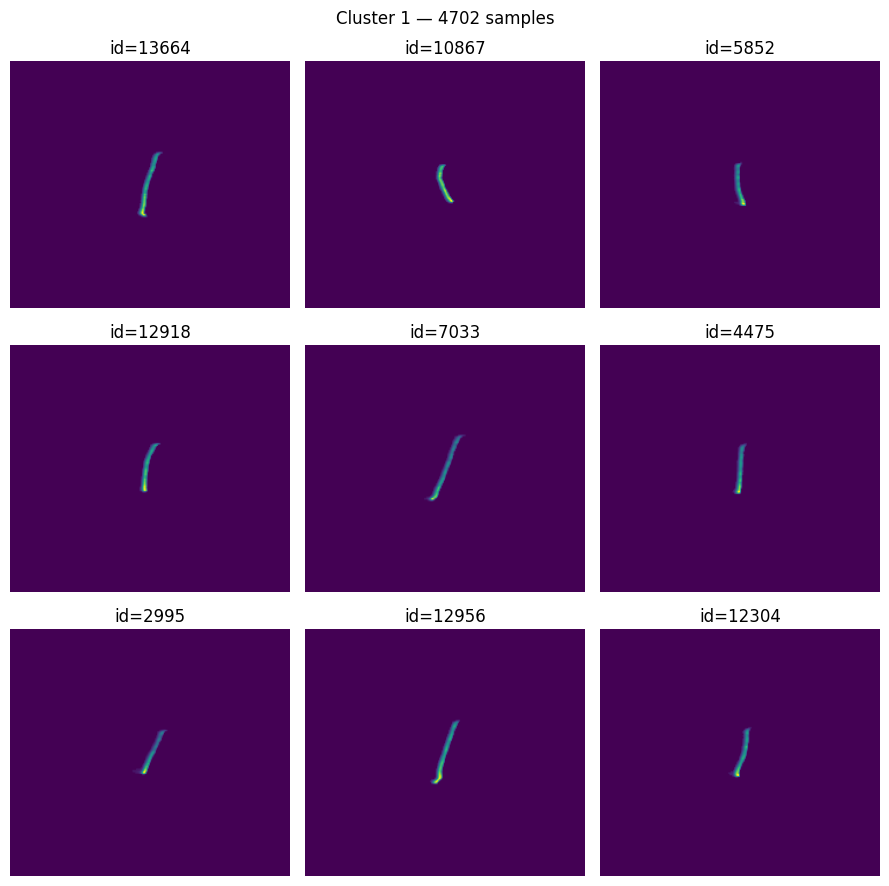

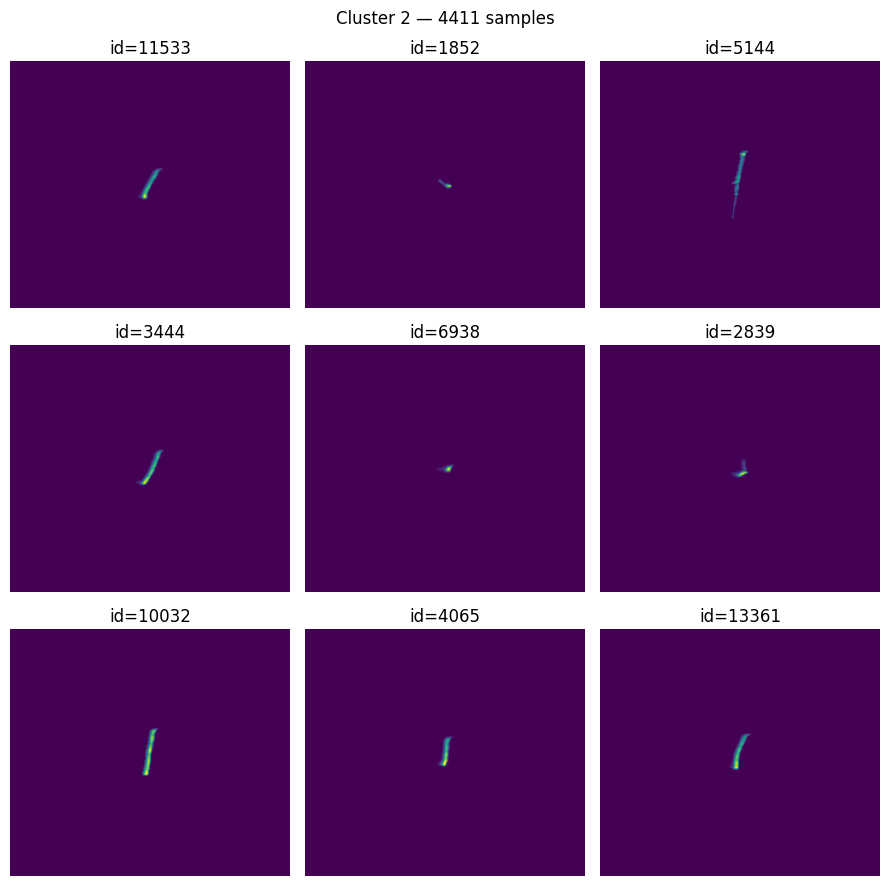

In [56]:
import math
unique_clusters = np.unique(labels_gmm)
for c in unique_clusters:
    idxs = np.where(labels_gmm == c)[0]
    if len(idxs) == 0:
        continue
    n_show = min(9, len(idxs))
    sel = np.random.choice(idxs, n_show, replace=False)
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        if i < n_show:
            ax.imshow(X_np[sel[i]], cmap='viridis', aspect='auto')
            ax.set_title(f"id={sel[i]}")
        ax.axis('off')
    plt.suptitle(f'Cluster {c} — {len(idxs)} samples')
    plt.tight_layout()
    plt.show()

In [57]:
data['cluster_gmm'] = labels_gmm

<Axes: xlabel='maxdiff', ylabel='Count'>

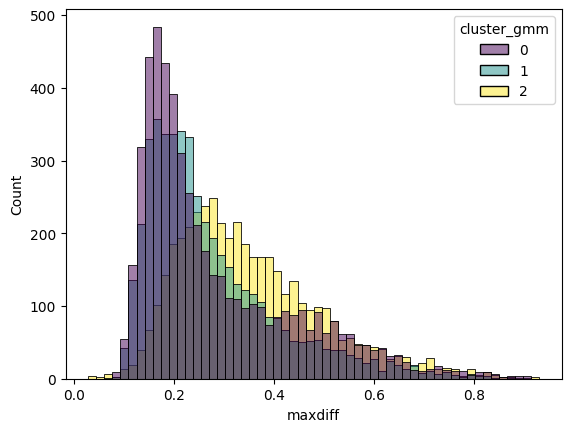

In [60]:
sns.histplot(data=data, x='maxdiff', hue='cluster_gmm', palette='viridis')

(1600.0, 2750.0)

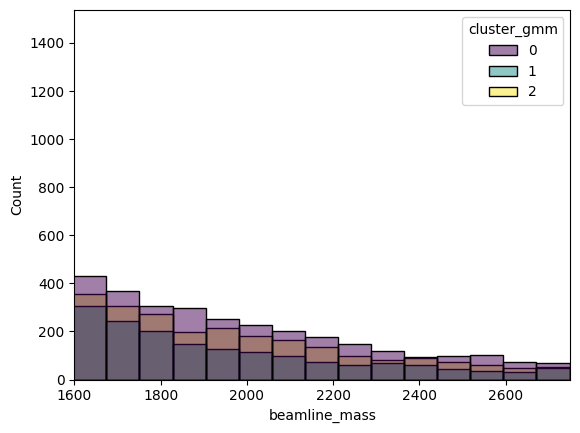

In [73]:
sns.histplot(data=data, x='beamline_mass', hue='cluster_gmm', palette='viridis')
plt.xlim(1600, 2750)